LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
Totals per bar: [200 200 200 200 200 200]
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.4.1_dilation/cifar100_dilation_outcomes.pdf


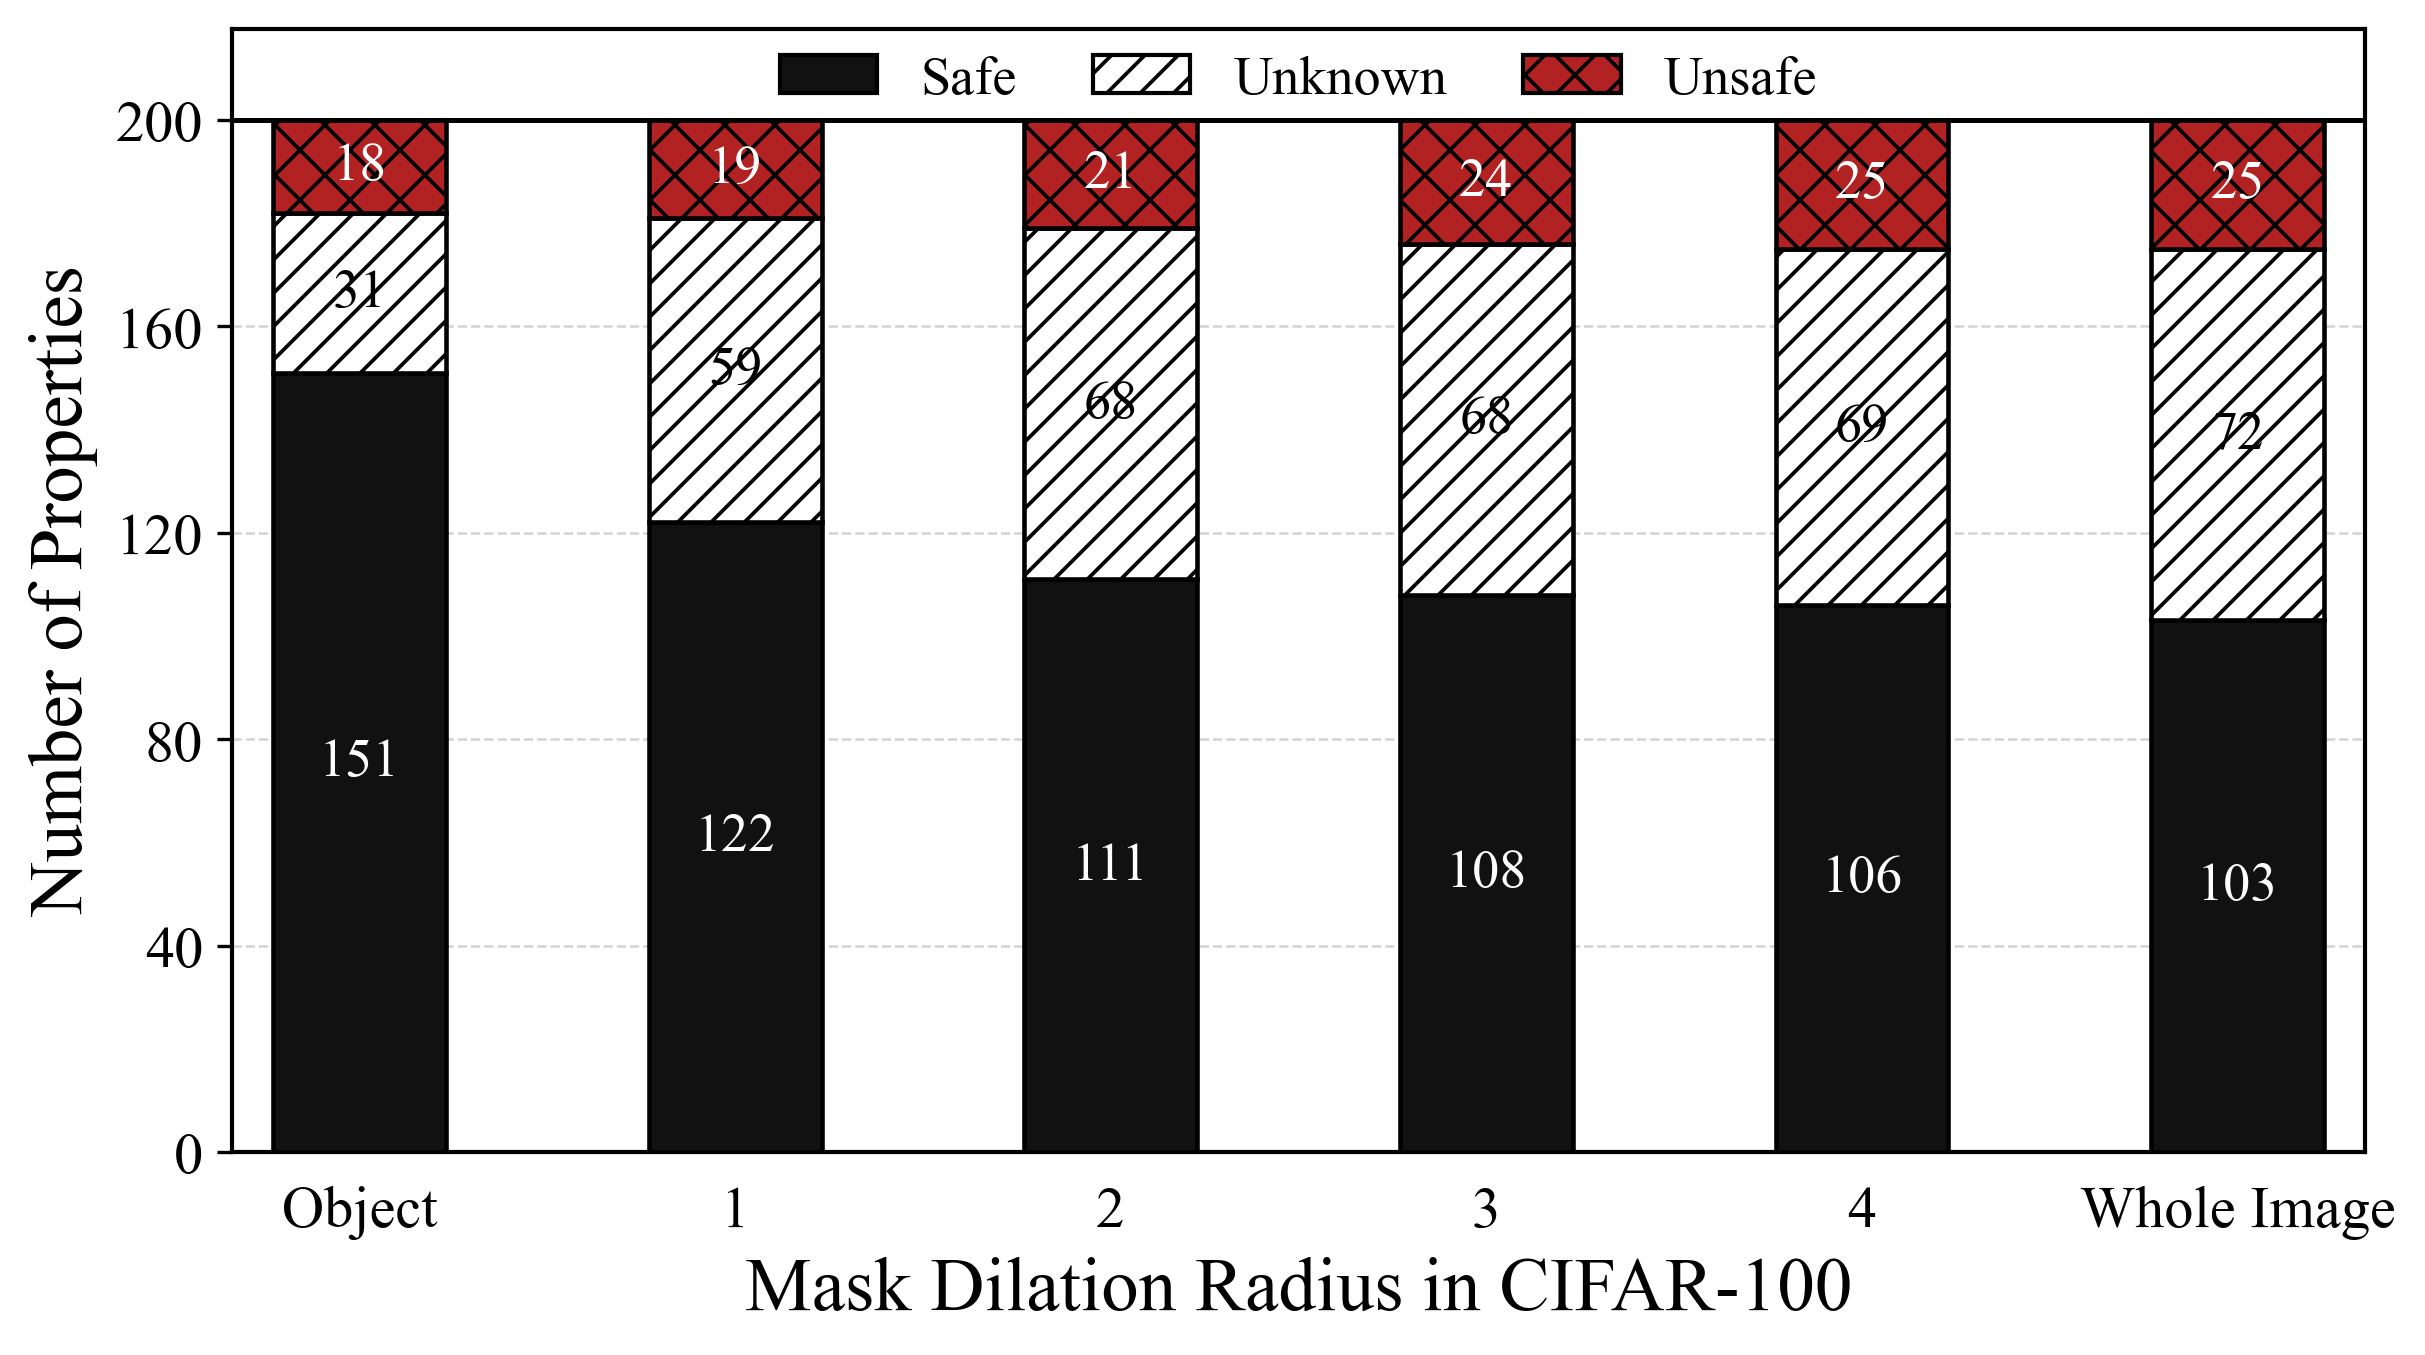

In [1]:
import logging
import os
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

if (Path("plots") / "5.4.1_dilation").exists():
    PLOT_DIR = Path("plots") / "5.4.1_dilation"
else:
    PLOT_DIR = Path.cwd()

CACHE_ROOT = PLOT_DIR / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

FORCE_TEX = True
BASE_FONT_SIZE = 16
AXIS_LABEL_SIZE = 18
AXIS_TITLE_SIZE = 18
TICK_LABEL_SIZE = 14
LEGEND_FONT_SIZE = 13
VALUE_LABEL_FONT_SIZE = 13
DEFAULT_FIGSIZE = (8.4, 4.8)
ORDER = ["Safe", "Unknown", "Unsafe"]
DILATION_LABELS = [
    "Object",
    "1", "2", "3", "4",
    "Whole Image"
]
OUTCOME_STYLE = {
    "Safe": {"facecolor": "#111111", "hatch": ""},
    "Unknown": {"facecolor": "white", "hatch": "///"},
    "Unsafe": {"facecolor": "#B22222", "hatch": "xx"},
}
TEXT_COLOR = {
    "Safe": "white",
    "Unknown": "black",
    "Unsafe": "white",
}

PDF_OUTPUT_PATH = PLOT_DIR / "cifar100_dilation_outcomes.pdf"
PNG_OUTPUT_PATH = PLOT_DIR / "cifar100_dilation_outcomes.png"

SAFE_COUNTS = np.array([151, 122, 111, 108, 106, 103])
UNKNOWN_COUNTS = np.array([31, 59, 68, 68, 69, 72])
UNSAFE_COUNTS = np.array([18, 19, 21, 24, 25, 25])
STACK_COUNTS = {
    "Safe": SAFE_COUNTS,
    "Unknown": UNKNOWN_COUNTS,
    "Unsafe": UNSAFE_COUNTS,
}


@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


@lru_cache(maxsize=2)
def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print(
            "LaTeX was requested but the current environment cannot compile a minimal "
            "TeX document. Falling back to Matplotlib serif text."
        )

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "Nimbus Roman",
            "STIXGeneral",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": AXIS_TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "hatch.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


def outcome_legend_handles():
    return [
        Patch(
            facecolor=OUTCOME_STYLE[outcome]["facecolor"],
            edgecolor="black",
            hatch=OUTCOME_STYLE[outcome]["hatch"],
            label=outcome,
        )
        for outcome in ORDER
    ]


def annotate_stack_labels(ax, bars, values, bottoms, outcome):
    for bar, value, bottom in zip(bars, values, bottoms):
        if value <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + value / 2,
            f"{int(value)}",
            ha="center",
            va="center",
            fontsize=VALUE_LABEL_FONT_SIZE,
            color=TEXT_COLOR[outcome],
        )


configure_plot_style()

totals = SAFE_COUNTS + UNKNOWN_COUNTS + UNSAFE_COUNTS
print("Totals per bar:", totals)

x = np.arange(len(DILATION_LABELS))
width = 0.46
ymax = max(int(totals.max()), 1)
label_offset = max(1.2, 0.02 * ymax)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE, dpi=300)

bottom = np.zeros_like(SAFE_COUNTS, dtype=float)
for outcome in ORDER:
    values = STACK_COUNTS[outcome]
    style = OUTCOME_STYLE[outcome]
    bars = ax.bar(
        x,
        values,
        width=width,
        bottom=bottom,
        color=style["facecolor"],
        edgecolor="black",
        linewidth=1.1,
        hatch=style["hatch"],
        zorder=3,
    )
    annotate_stack_labels(ax, bars, values, bottom, outcome)
    bottom = bottom + values

ax.axhline(ymax, color="black", linewidth=1.2, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(DILATION_LABELS)
ax.set_ylabel("Number of Properties")
ax.set_xlabel("Mask Dilation Radius in CIFAR-100")
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.55)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(axis="x", length=0, pad=8)
ax.margins(x=0.02)
ax.set_ylim(0, ymax + 4.4 * label_offset)
ax.legend(
    handles=outcome_legend_handles(),
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    handlelength=1.8,
    columnspacing=1.4,
)

fig.tight_layout()
fig.savefig(PDF_OUTPUT_PATH, bbox_inches="tight")
# fig.savefig(PNG_OUTPUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved: {PDF_OUTPUT_PATH}")
# print(f"Saved: {PNG_OUTPUT_PATH}")

if "agg" in mpl.get_backend().lower():
    plt.close(fig)
else:
    plt.show()
